In [1]:
!pip install kaggle 


Defaulting to user installation because normal site-packages is not writeable


In [2]:
!kaggle competitions download -c house-prices-advanced-regression-techniques -p ./data


house-prices-advanced-regression-techniques.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
import os 
os.makedirs(os.path.expanduser('~/.kaggle') , exist_ok=True)

import shutil
shutil.copy(r'C:\Users\Admin\Downloads\kaggle (1).json',
            os.path.expanduser('~/.kaggle/kaggle.json'))

import stat
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json') , stat.S_IRUSR | stat.S_IWUSR)

print("Done!")

Done!


In [4]:
!kaggle competitions download -c house-prices-advanced-regression-techniques -p ./data

house-prices-advanced-regression-techniques.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
import zipfile
with zipfile.ZipFile('./data/house-prices-advanced-regression-techniques.zip', 'r') as z:
    z.extractall('./data')
print("Unzipped!")

Unzipped!


In [6]:
import os
for f in os.listdir('./data'):
    print(f)

data_description.txt
house-prices-advanced-regression-techniques.zip
sample_submission.csv
test.csv
train.csv


In [7]:
import pandas as pd 
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')
print(train.shape)
train.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Test shape: (1459, 80)

Target variable stats:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


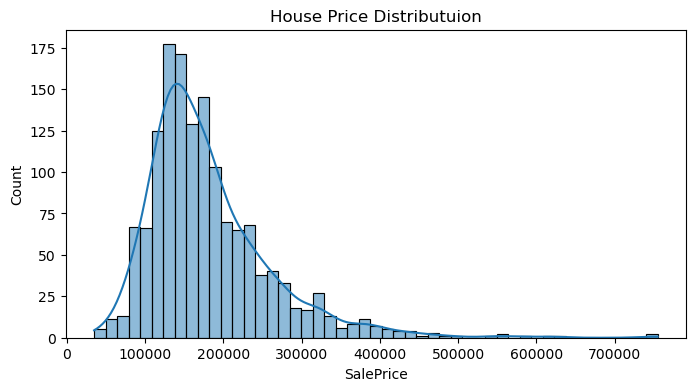

In [8]:
import pandas as pd 
import numpy as np
import matplotlib .pyplot as plt
import seaborn as sns

train = pd.read_csv('./data/train.csv')
print("Test shape:" , test.shape)
print("\nTarget variable stats:")
print(train['SalePrice'].describe())

#Visualize target
plt.figure(figsize=(8,4))
sns.histplot(train['SalePrice'], kde=True)
plt.title('House Price Distributuion')
plt.show()

Columns with missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


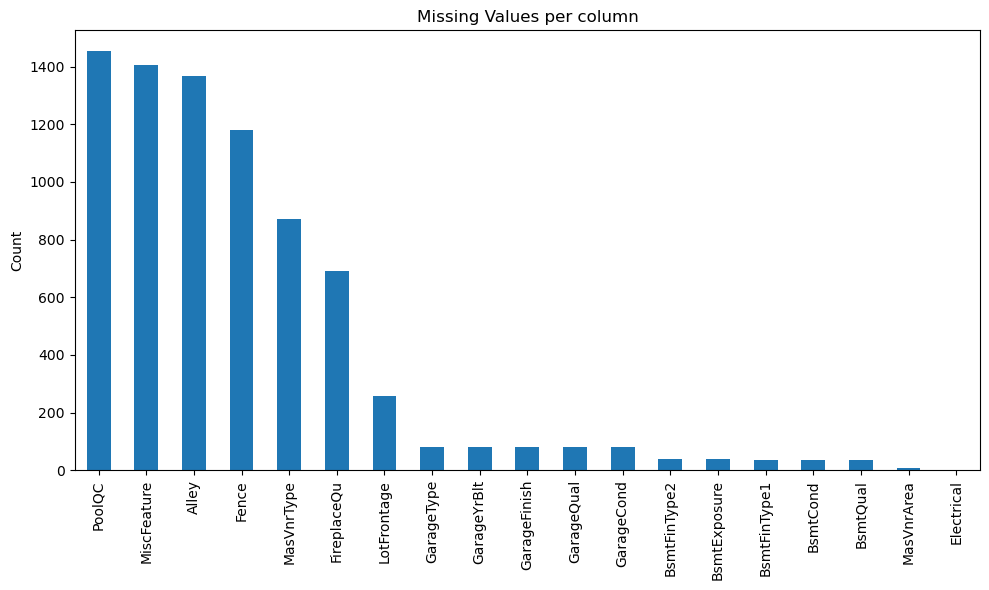

In [9]:
#Check missing vallues
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

#Visualizing the missing values
plt.figure(figsize = (10,6))
missing.plot(kind = 'bar')
plt.title('Missing Values per column')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [10]:
# Combine train and test for consistent processing 
all_data = pd.concat([train.drop('SalePrice' , axis=1), test] ,axis=0)

#Fill categorical missing with 'None'
cat_cols = all_data.select_dtypes(include='object').columns
all_data[cat_cols] = all_data[cat_cols].fillna('None')

#Fill numurical missing with 0
num_cols = all_data.select_dtypes(include='number').columns
all_data[num_cols] = all_data[num_cols].fillna(0)

print("Missing values remaining:", all_data.isnull().sum().sum())
print("Done!✅")

Missing values remaining: 0
Done!✅


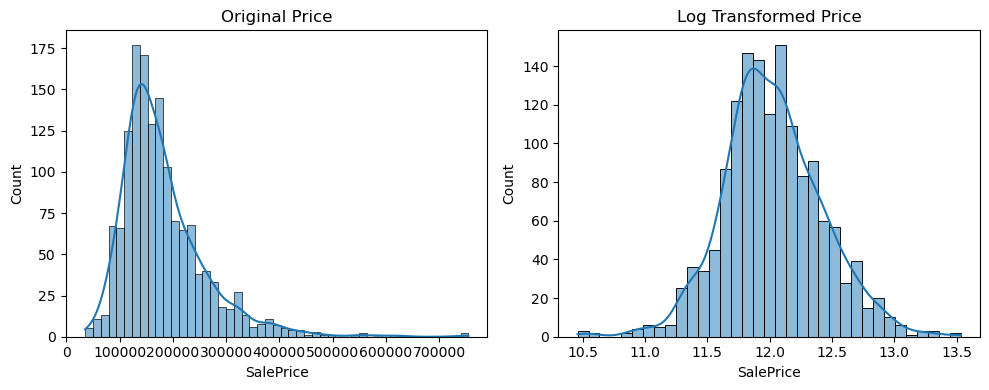

In [11]:
# Log transform SalePrice
y = np.log1p(train['SalePrice'])

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(train['SalePrice'],kde=True)
plt.title('Original Price')

plt.subplot(1,2,2)
sns.histplot(y ,kde=True)
plt.title('Log Transformed Price')
plt.tight_layout()
plt.show()

In [16]:
# New Useful Features

all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF'] 
all_data['TotalBath'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] + all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['Remodeled'] = (all_data['YearRemodAdd'] != all_data['YearBuilt']).astype(int)

print("New Features Added ✅")
print(all_data[['TotalSF','TotalBath','HouseAge','Remodeled']].head())

New Features Added ✅
   TotalSF  TotalBath  HouseAge  Remodeled
0   2566.0        3.5         5          0
1   2524.0        2.5        31          0
2   2706.0        3.5         7          1
3   2473.0        2.0        91          1
4   3343.0        3.5         8          0


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = all_data.select_dtypes(include='object').columns

for col in cat_cols:
    all_data[col] = le.fit_transform(all_data[col].astype(str))

print("Categories encoded ✅")
print("Total features:" , all_data.shape[1])

Categories encoded ✅
Total features: 84


In [21]:
X = all_data[:len(train)]
X_test = all_data[len(train):]

print(" X shape:", X.shape)
print("X_test shape:", X_test.shape)
print("Ready for modeling ✅")

 X shape: (1460, 84)
X_test shape: (1459, 84)
Ready for modeling ✅


In [30]:
!pip install xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.metrics import mean_absolute_error , mean_squared_error
import numpy as np
print("Imports done ✅")

#Split data

X_train , X_val , y_train , y_val = train_test_split(X,y,test_size = 0.2 , random_state= 42)
print("Train size:", X_train.shape)
print("Val size:", X_val.shape)

#Train Model

model = XGBRegressor(
    n_estimators = 1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse'
)
model.fit(X_train , y_train,
          eval_set=[(X_val , y_val)],
          verbose=100)

#Evaluate
preds =model.predict(X_val)
preds_actual = np.expm1(preds)
y_actual = np.expm1(y_val)

mae = mean_absolute_error(y_actual , preds_actual)
rmse = np.sqrt(mean_squared_error(y_actual , preds_actual))

print(f"\nMAE: ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print("Model trained ✅")

Defaulting to user installation because normal site-packages is not writeable
Imports done ✅
Train size: (1168, 84)
Val size: (292, 84)
[0]	validation_0-rmse:0.41690
[100]	validation_0-rmse:0.13996
[200]	validation_0-rmse:0.13778
[212]	validation_0-rmse:0.13770

MAE: $15,538
RMSE: $26,376
Model trained ✅


In [31]:
!pip install shap
import shap
print("SHAP installed ✅")

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 3.8 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

SHAP installed ✅


In [32]:
# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)
print("SHAP values calaculated ✅")

SHAP values calaculated ✅


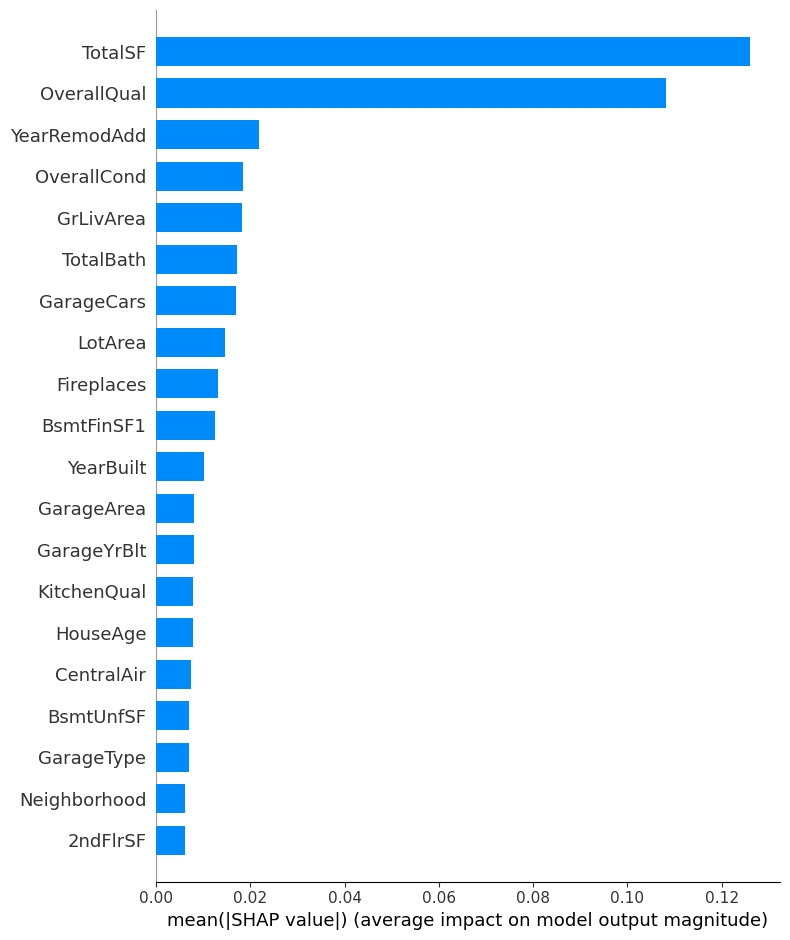

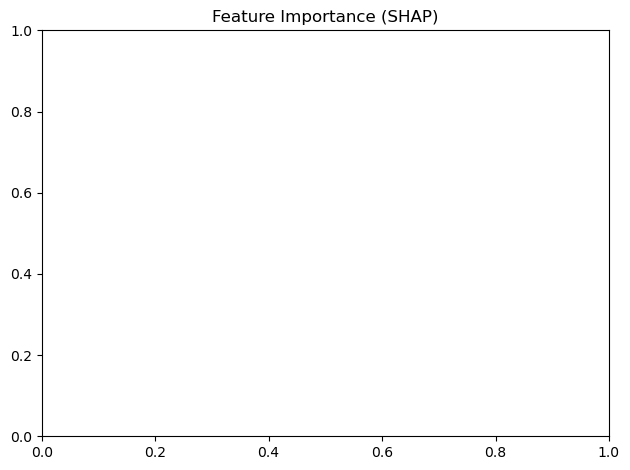

In [33]:
plt.figure(figsize=(10,8))
shap.summary_plot(shap_values, X_val,
                  feature_names = X.columns.tolist(),
                  plot_type="bar")
plt.title("Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

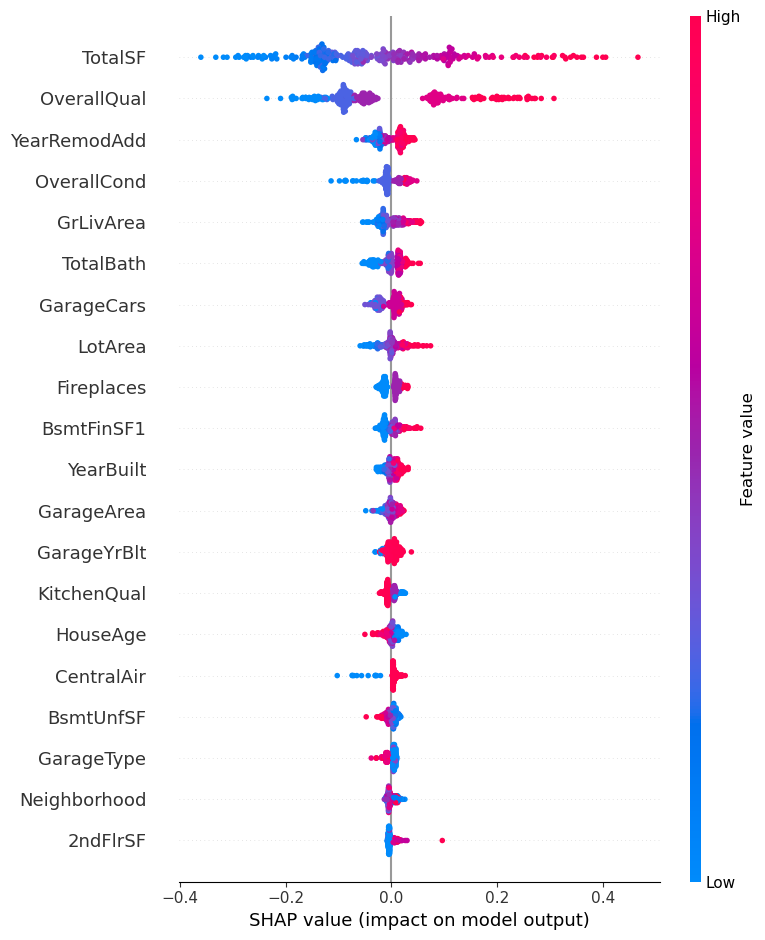

In [37]:
shap.summary_plot(shap_values, X_val , feature_names = X.columns.tolist())
plt.show()

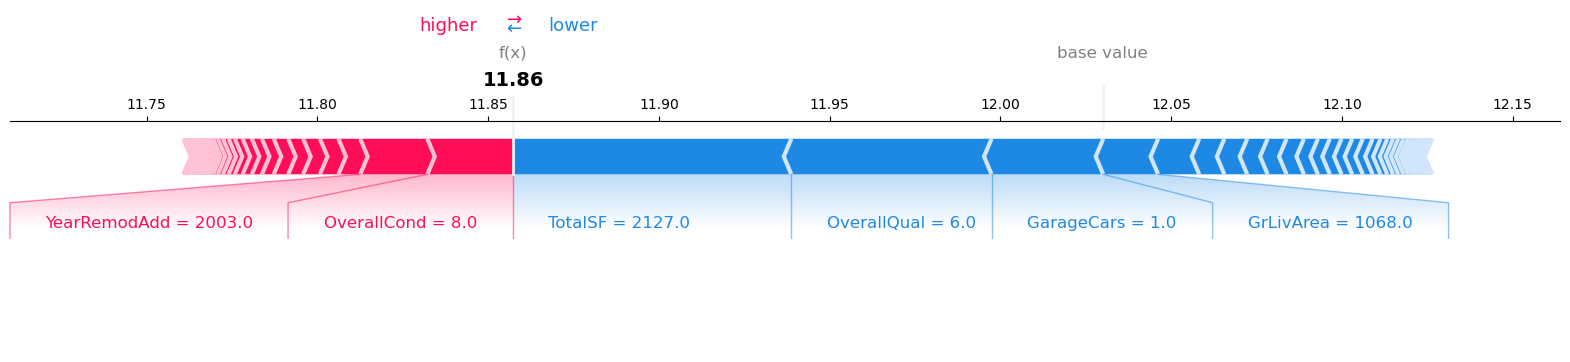

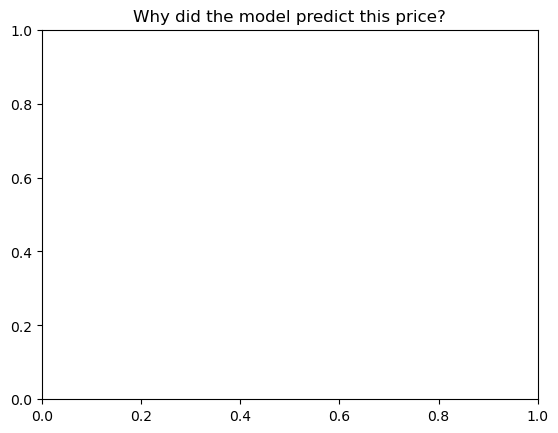

In [38]:
#Explain first house prediction
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_val.iloc[0],
    feature_names=X.columns.tolist(),matplotlib=True
)
plt.title("Why did the model predict this price?")
plt.show()

In [40]:
import numpy as np
import pandas as pd

# Step 1: Make predictions
test_preds = model.predict(X_test)

# Step 2: Convert from log scale
test_preds_actual = np.expm1(test_preds)

# Step 3: Create submission
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': test_preds_actual
})

# Step 4: Save
submission.to_csv(r'C:\Users\Admin\data\submission.csv', index=False)
print("Saved ✅")
print(submission.head())

Saved ✅
     Id      SalePrice
0  1461  122103.921875
1  1462  158215.812500
2  1463  182920.734375
3  1464  187970.531250
4  1465  185024.718750
